In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data
fake = pd.read_csv('../dataset/Fake.csv')
real = pd.read_csv('../dataset/True.csv')

In [3]:
# Add labels
fake['label'] = 0
real['label'] = 1

In [4]:
# Combine
df = pd.concat([fake, real], ignore_index=True)
df = df[['title', 'text', 'label']]
df['content'] = df['title'] + " " + df['text']
df.dropna(inplace=True)

In [5]:
print(df.shape)
print(df['label'].value_counts())
df.head()

(44898, 4)
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,label,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0,Pope Francis Just Called Out Donald Trump Dur...


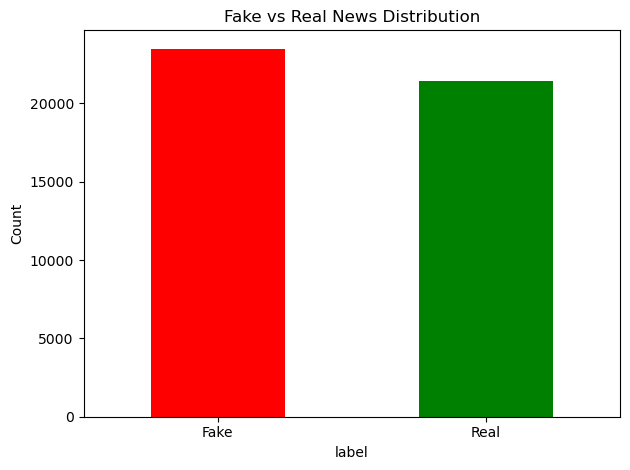

In [6]:
# Distribution plot
df['label'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Fake vs Real News Distribution')
plt.xticks([0, 1], ['Fake', 'Real'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
# Average article length
df['content_length'] = df['content'].apply(len)
print("Average Fake article length:", df[df['label']==0]['content_length'].mean().round())
print("Average Real article length:", df[df['label']==1]['content_length'].mean().round())

Average Fake article length: 2643.0
Average Real article length: 2449.0


In [8]:
import seaborn as sns

In [9]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicate articles
print("\nDuplicate articles:", df.duplicated().sum())

Missing values:
title             0
text              0
label             0
content           0
content_length    0
dtype: int64

Duplicate articles: 5793


In [10]:
# Sample fake article
print("\n--- Sample FAKE article ---")
print(df[df['label']==0]['content'].iloc[0][:300])

# Sample real article
print("\n--- Sample REAL article ---")
print(df[df['label']==1]['content'].iloc[0][:300])


--- Sample FAKE article ---
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had j

--- Sample REAL article ---
As U.S. budget fight looms, Republicans flip their fiscal script WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged b


In [11]:
# Remove duplicates
df = df.drop_duplicates(subset=['content'])
print("Shape after removing duplicates:", df.shape)

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shuffled successfully")
print(df['label'].value_counts())

Shape after removing duplicates: (39105, 5)
Dataset shuffled successfully
label
1    21197
0    17908
Name: count, dtype: int64


In [12]:
# Save cleaned dataset
df.to_csv('../dataset/cleaned_news_data.csv', index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
